In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random


In [2]:
from nn_interpretation.signal_generator import signal_generator

x_data, y_data, signal_length = signal_generator(num_instances=10000, start=0, end=32.0, step=0.2, noise_sigma=0.1)

In [19]:
class net(torch.nn.Module):

    def __init__(self):
        super(net, self).__init__()
        # Single hidden layer with no bias
        self.fc = nn.Linear(signal_length,signal_length, bias = False)

    def forward(self,x):
      x = self.fc(x)
      return x

In [5]:
torch.cuda.is_available()

True

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = net().to(device)
x_data = x_data.to(device)
y_data = y_data.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Number of params
pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of parameters:{pytorch_total_params}')
print(signal_length)

Using device: cuda
Number of parameters:25600
160


In [7]:
# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(x_data)
    loss = criterion(outputs, y_data)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [50/1000], Loss: 0.0032
Epoch [100/1000], Loss: 0.0020
Epoch [150/1000], Loss: 0.0018
Epoch [200/1000], Loss: 0.0017
Epoch [250/1000], Loss: 0.0017
Epoch [300/1000], Loss: 0.0016
Epoch [350/1000], Loss: 0.0016
Epoch [400/1000], Loss: 0.0016
Epoch [450/1000], Loss: 0.0016
Epoch [500/1000], Loss: 0.0016
Epoch [550/1000], Loss: 0.0016
Epoch [600/1000], Loss: 0.0016
Epoch [650/1000], Loss: 0.0016
Epoch [700/1000], Loss: 0.0016
Epoch [750/1000], Loss: 0.0016
Epoch [800/1000], Loss: 0.0016
Epoch [850/1000], Loss: 0.0016
Epoch [900/1000], Loss: 0.0016
Epoch [950/1000], Loss: 0.0016
Epoch [1000/1000], Loss: 0.0016


In [17]:
W = model.fc.weight.data
W = W.cpu().detach().numpy()

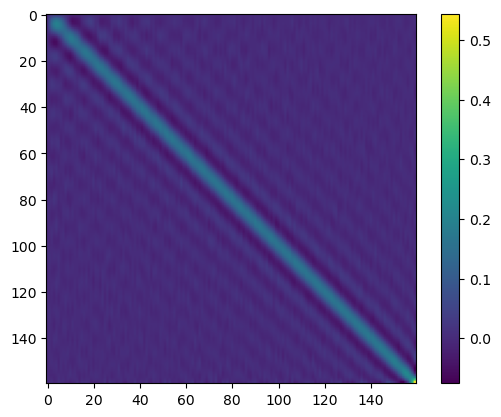

In [18]:
plt.imshow(W)
plt.colorbar()
plt.show()

In [20]:
class net(torch.nn.Module):

    def __init__(self):
        super(net, self).__init__()
        self.fc1 = nn.Linear(signal_length, signal_length, bias=False)
        self.fc2 = nn.Linear(signal_length, signal_length, bias=False)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = net().to(device)
x_data = x_data.to(device)
y_data = y_data.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Number of params
pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of parameters:{pytorch_total_params}')
print(signal_length)

Using device: cuda
Number of parameters:51200
160


In [22]:
# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(x_data)
    loss = criterion(outputs, y_data)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [50/1000], Loss: 0.0021
Epoch [100/1000], Loss: 0.0017
Epoch [150/1000], Loss: 0.0017
Epoch [200/1000], Loss: 0.0016
Epoch [250/1000], Loss: 0.0016
Epoch [300/1000], Loss: 0.0016
Epoch [350/1000], Loss: 0.0016
Epoch [400/1000], Loss: 0.0016
Epoch [450/1000], Loss: 0.0016
Epoch [500/1000], Loss: 0.0017
Epoch [550/1000], Loss: 0.0016
Epoch [600/1000], Loss: 0.0017
Epoch [650/1000], Loss: 0.0017
Epoch [700/1000], Loss: 0.0016
Epoch [750/1000], Loss: 0.0016
Epoch [800/1000], Loss: 0.0016
Epoch [850/1000], Loss: 0.0016
Epoch [900/1000], Loss: 0.0016
Epoch [950/1000], Loss: 0.0016
Epoch [1000/1000], Loss: 0.0016


In [23]:
W1 = model.fc1.weight.data
W1= W1.cpu().detach().numpy()

W2 = model.fc2.weight.data
W2 = W2.cpu().detach().numpy()

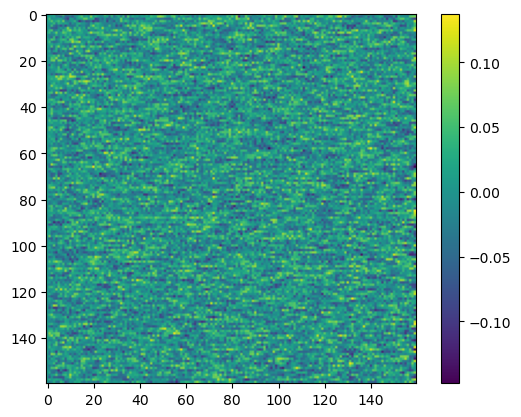

In [24]:
plt.imshow(W1)
plt.colorbar()
plt.show()

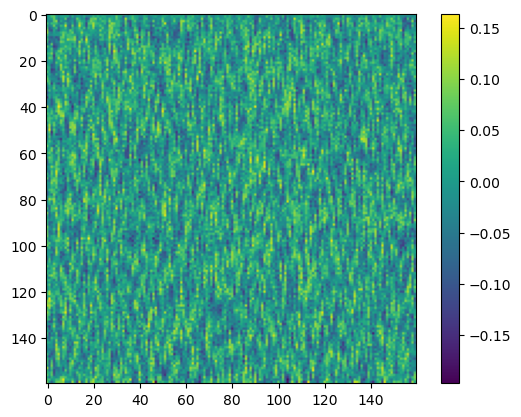

In [25]:
plt.imshow(W2)
plt.colorbar()
plt.show()

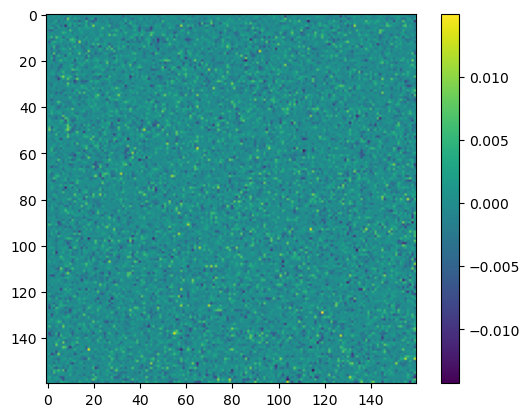

In [28]:
plt.imshow(np.multiply(W1, W2))
plt.colorbar()
plt.show()

In [29]:
import numpy as np
from scipy.optimize import minimize
from scipy.linalg import toeplitz, inv, norm

def get_fourdif_2nd_order(N):
    """
    Generates the 2nd order Fourier spectral differentiation matrix.
    Recreates the core functionality of MATLAB's fourdif(N, 2)
    based on standard spectral methods.
    """
    c = np.zeros(N)
    
    # Construct the first column of the Toeplitz matrix
    if N % 2 == 0:
        c[0] = -(N**2 + 2) / 12.0
        k = np.arange(1, N)
        c[1:] = 0.5 * ((-1)**k) / (np.sin(k * np.pi / N)**2)
    else:
        c[0] = -(N**2 - 1) / 12.0
        k = np.arange(1, N)
        c[1:] = 0.5 * ((-1)**k) * np.cos(k * np.pi / N) / (np.sin(k * np.pi / N)**2)
    
    # D is a symmetric Toeplitz matrix for the 2nd derivative
    D = toeplitz(c)
    return D

def descramble(S, n_iter=400, guess=None):
    """
    Generates a weight matrix descrambler for a particular layer in
    a neural network using Tikhonov smoothness criterion.
    
    Parameters:
        S (np.ndarray): A matrix containing, in its columns, the outputs
                        of the preceding layers of the neural network for
                        a (preferably large) number of reasonable inputs.
        n_iter (int): Maximum number of L-BFGS-B iterations. Default is 400.
        guess (np.ndarray): [optional] The initial guess for the descrambling
                            transform generator. Default is a zeros matrix.
                            
    Returns:
        P (np.ndarray): Descrambling matrix.
        Q (np.ndarray): Generator matrix.
    """
    # Check consistency
    if not isinstance(S, np.ndarray) or not np.isrealobj(S):
        raise ValueError("S must be a real numpy array.")
    if not isinstance(n_iter, int) or n_iter < 1:
        raise ValueError("n_iter must be a positive integer.")
        
    out_dim = S.shape[0]
    opt_dim = (out_dim**2 - out_dim) // 2
    
    # Lower triangle index array
    lt_idx = np.tril_indices(out_dim, -1)
    
    # Default guess is zero
    if guess is None:
        q0 = np.zeros(opt_dim)
    else:
        q0 = guess[lt_idx]
        
    # Get second derivative operator
    D = get_fourdif_2nd_order(out_dim)
    
    # Precompute some steps and scale
    SST = S @ S.T
    SST = out_dim * SST / norm(SST, 2)
    DTD = D.T @ D
    DTD = out_dim * DTD / norm(DTD, 2)
    U = np.eye(out_dim)
    
    # Regularisation signal (Objective Function)
    def reg_sig(q):
        # Form the generator
        Q = np.zeros((out_dim, out_dim))
        Q[lt_idx] = q
        Q = Q - Q.T
        
        # Re-use the inverse
        iUpQ = inv(U + Q)
        
        # Run Cayley transform
        P = iUpQ @ (U - Q)
        
        # Re-use triple product
        DTDPSST = DTD @ P @ SST
        
        # Compute Tikhonov norm
        eta = np.trace(DTDPSST @ P.T)
        
        # Compute Tikhonov norm gradient
        eta_grad = -2.0 * iUpQ.T @ DTDPSST @ (U + P).T
        
        # Antisymmetrise the gradient
        eta_grad = eta_grad - eta_grad.T
        
        # Extract the lower triangle
        eta_grad_1d = eta_grad[lt_idx]
        
        return eta, eta_grad_1d

    # Optimisation using L-BFGS-B 
    options = {
        'maxiter': n_iter,
        'disp': True, # Set to False to silence solver output
    }
    
    # Run the bounded memory BFGS minimizer
    res = minimize(reg_sig, q0, method='L-BFGS-B', jac=True, options=options)
    q_opt = res.x
    
    # Form descramble generator from the optimized values
    Q = np.zeros((out_dim, out_dim))
    Q[lt_idx] = q_opt
    Q = Q - Q.T
    
    # Run final Cayley transform
    P = inv(U + Q) @ (U - Q)
    
    return P, Q

In [31]:
S = W1 @ x_data.cpu().detach().numpy().T
P, Q = descramble(S, n_iter=1000)

C:\Users\tajwa\AppData\Local\Temp\ipykernel_20852\3950880391.py:109: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(reg_sig, q0, method='L-BFGS-B', jac=True, options=options)


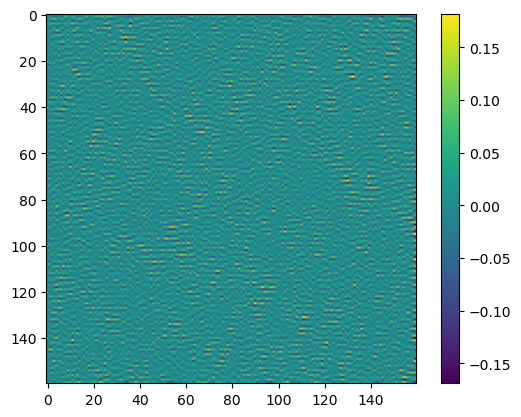

In [33]:
Wd = P@W1

plt.imshow(Wd)
plt.colorbar()
plt.show()

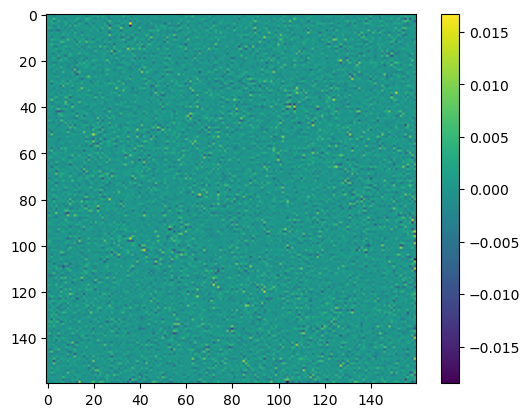

In [34]:
plt.imshow(Wd*W2)
plt.colorbar()
plt.show()